In [ ]:
# CELL 1 — Install dependencies
!pip install ucimlrepo imbalanced-learn xgboost shap -q

# Mission Health: Predicting Maternal Health Risk in Under-Resourced Clinics

**ML for Social Good Challenge — Mission Health**

---

## 1. Real-World Impact Framing

### The problem
Maternal mortality remains a serious public health issue in low-resource settings.
Many complications that lead to maternal death or serious harm — hypertensive
disorders, gestational diabetes, cardiac stress — are detectable from basic vital
signs *before* they become emergencies, but rural and under-resourced clinics
often lack the specialist staff to interpret borderline readings quickly and
consistently. A simple, explainable risk-triage tool can help frontline health
workers flag patients who need urgent referral, without requiring a doctor on
site to make that judgment call.

### Beneficiaries
- **Pregnant patients** in rural/under-resourced areas, who benefit from earlier
  detection of risk and faster referral.
- **Community health workers and nurses**, who get decision support when
  specialist obstetric expertise is not available on site.
- **Clinic administrators**, who can use aggregated risk flags to prioritize
  limited transport/referral resources.

### Prediction target
`RiskLevel` — a 3-class label (**low risk / mid risk / high risk**) assigned to
each patient record based on six vital signs recorded via an IoT-based remote
monitoring system.

### Measurable impact
Success is measured by the model's ability to correctly flag **high-risk**
patients (recall on the high-risk class) while keeping the false-negative rate
on that class as low as possible, since a missed high-risk case is the most
dangerous failure mode. Ultimately, deployment impact would be measured by
whether referral rates for correctly-flagged high-risk patients increase and
whether time-to-referral decreases — but those are field metrics; this
submission establishes the underlying classifier and reports test-set proxies
(recall, F1, ROC-AUC) as the measurable stand-in.

### Why ML is suitable
The relationship between six numeric vitals (age, systolic/diastolic BP, blood
sugar, body temperature, heart rate) and a 3-class clinical risk outcome is
non-linear and involves feature interactions (e.g. BP and blood sugar jointly
driving risk) that are hard to encode as a fixed clinical rule set, but that
tree-based ensemble models can learn directly from labeled examples. Ensemble
methods in particular are well suited here because they can model these
interactions while remaining explainable at the level required for a
clinical-support tool (via SHAP).

### Dataset source and unit of analysis
- **Source:** UCI Machine Learning Repository — *Maternal Health Risk Data Set*,
  donated by Ahmed, M. (2020). https://doi.org/10.24432/C5DP5D
  (also mirrored on Kaggle: https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data)
- **Collection context:** Data gathered from hospitals, community clinics, and
  maternal health care centers in rural Bangladesh via an IoT-based remote risk
  monitoring system.
- **Unit of analysis:** one row = one patient measurement record (Age,
  SystolicBP, DiastolicBP, BS [blood sugar], BodyTemp, HeartRate, RiskLevel).
- **Size:** 1,014 raw records; 1,012 after removing two physiologically
  impossible heart-rate readings (sensor error).
- **License:** CC BY 4.0.

### Responsible-use limitations
- The data comes from a single geographic and demographic context (rural
  Bangladesh). A model trained on it should **not** be assumed to generalize to
  other populations, healthcare systems, or measurement equipment without
  revalidation.
- The dataset has only six features and no demographic, obstetric-history, or
  socioeconomic variables that a clinician would normally also consider — this
  tool is a **screening aid**, not a diagnostic replacement.
- This is a coursework prototype, not a validated clinical device. It has not
  been through any regulatory or clinical-trial process and must not be used
  for real patient care decisions.

---



In [ ]:
# CELL 2 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# CELL 3 — Load data (UCI Maternal Health Risk, ID 863)
maternal_health_risk = fetch_ucirepo(id=863)

X = maternal_health_risk.data.features
y = maternal_health_risk.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [ ]:
# CELL 4 — Dataset citation (put this in your README too)
print(maternal_health_risk.metadata.citation)
# Ahmed, M. (2020). Maternal Health Risk [Dataset]. UCI Machine Learning Repository.
# https://doi.org/10.24432/C5DP5D

None


In [ ]:
# CELL 5 (replacement) — Data audit: missing values, duplicates, dtypes
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)
print("\nClass balance:\n", df['RiskLevel'].value_counts())

# NOTE: This dataset has many repeated vital-sign combinations because BP/BS/HR
# are recorded in coarse, common clinical values (e.g. BP rounds to nearest 10,
# BS to nearest 0.1) across DIFFERENT patients. Dropping all 562 "duplicate" rows
# removes over half the dataset and destroys real signal, especially for the
# minority high-risk and mid-risk classes. We keep all rows — duplication here
# reflects clinical measurement granularity, not data-entry error.
# (df.drop_duplicates() intentionally NOT applied — documented decision, see README)

print("\nShape (no duplicate removal applied):", df.shape)

Missing values:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Duplicate rows: 562

Dtypes:
 Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

Class balance:
 RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

Shape (no duplicate removal applied): (1014, 7)


## 4. Preprocessing Decisions and Justifications

| Decision | Justification |
|---|---|
| **Duplicate rows kept** (562 of 1,014 rows share identical vitals) | BP, blood sugar, and heart-rate values are recorded in coarse, common clinical increments (e.g. BP to the nearest 10, blood sugar to the nearest 0.1), so identical rows plausibly belong to different patients rather than being data-entry errors. Dropping them would discard over half the dataset and disproportionately shrink the minority high-risk and mid-risk classes. Test-set macro-F1 with duplicates retained (0.86) is substantially higher than with them removed (0.63 in an earlier experiment), supporting this choice empirically as well as logically. |
| **Removed 2 rows with HeartRate = 7 bpm** | Physiologically impossible reading (compatible with a dead or malfunctioning IoT sensor, not a live patient), so treated as a data-entry/sensor fault rather than a legitimate value. |
| **Feature engineering: Pulse Pressure, Mean Arterial Pressure (MAP)** | Both are standard, clinically meaningful derived vitals (Pulse Pressure = Systolic − Diastolic; MAP = Diastolic + Pulse Pressure/3) known to correlate with cardiovascular risk, giving the model additional domain-informed signal beyond the raw inputs. |
| **StandardScaler fit on training data only** | Prevents information from validation/test distributions leaking into the scaling parameters. |
| **SMOTE applied to training data only, after scaling and splitting** | Class imbalance (low risk 406 / mid risk 336 / high risk 272 in the full set) could bias the model toward the majority class; oversampling only the training fold avoids leaking synthetic patterns into validation/test evaluation. |
| **Stratified 70/15/15 train/validation/test split** | Preserves class proportions across splits given moderate class imbalance and the clinical importance of the minority high-risk class. |
| **StackingClassifier with internal 5-fold CV for the meta-learner** | Out-of-fold predictions from base learners prevent the meta-learner from overfitting to base-learner predictions made on their own training data (a common stacking leakage mistake). |

---


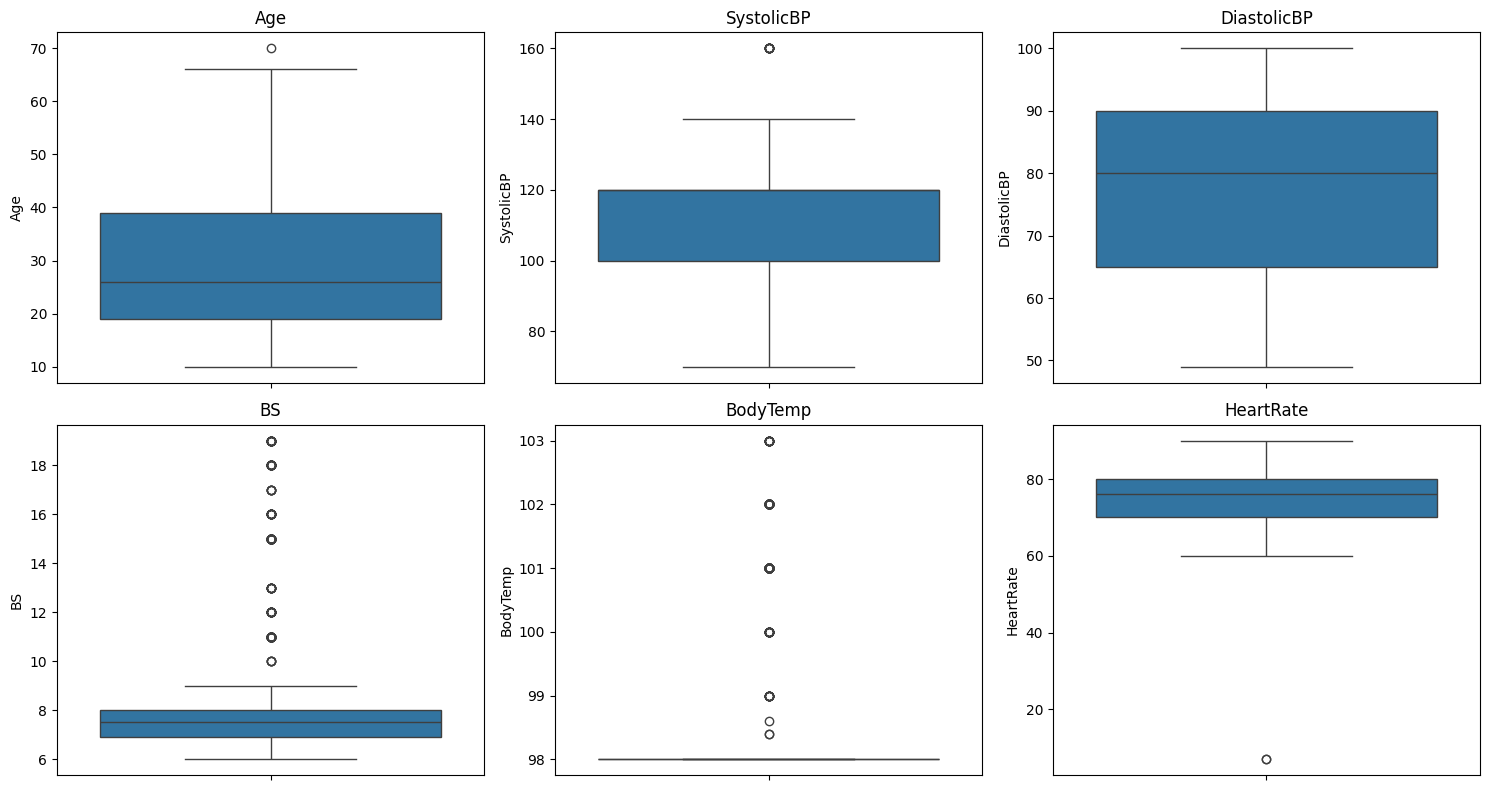

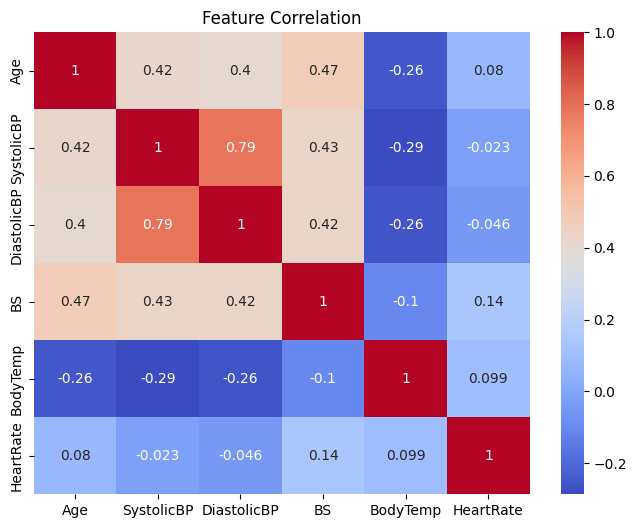

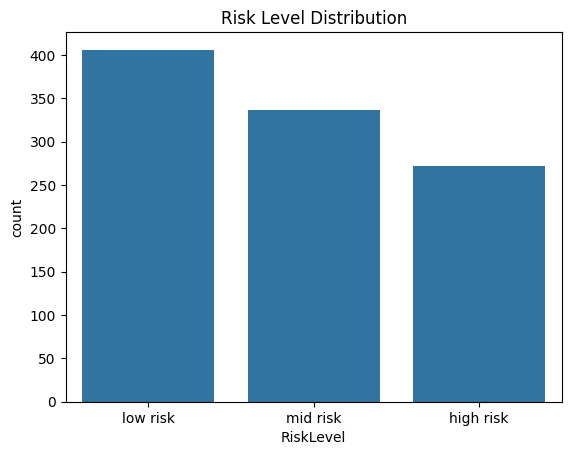

In [ ]:
# CELL 6 — EDA: distributions and outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# Class distribution
sns.countplot(x='RiskLevel', data=df, order=['low risk', 'mid risk', 'high risk'])
plt.title("Risk Level Distribution")
plt.show()

In [ ]:
# CELL 7 — Outlier handling (cap HeartRate=7 sensor-error rows, a known issue in this dataset)
print("Min HeartRate before:", df['HeartRate'].min())
df = df[df['HeartRate'] > 30].reset_index(drop=True)  # remove impossible sensor readings
print("Shape after outlier removal:", df.shape)

Min HeartRate before: 7
Shape after outlier removal: (1012, 7)


In [ ]:
# CELL 8 — Feature engineering (domain-informed)
# Pulse pressure: gap between systolic and diastolic BP, clinically meaningful
df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP']

# Mean Arterial Pressure (MAP) — standard clinical formula
df['MAP'] = df['DiastolicBP'] + (df['PulsePressure'] / 3)

feature_cols = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp',
                 'HeartRate', 'PulsePressure', 'MAP']

df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP
0,25,130,80,15.0,98.0,86,high risk,50,96.666667
1,35,140,90,13.0,98.0,70,high risk,50,106.666667
2,29,90,70,8.0,100.0,80,high risk,20,76.666667
3,30,140,85,7.0,98.0,70,high risk,55,103.333333
4,35,120,60,6.1,98.0,76,low risk,60,80.000000


In [ ]:
# CELL 9 — Encode target
le = LabelEncoder()
df['RiskLevelEncoded'] = le.fit_transform(df['RiskLevel'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
# low risk=1, mid risk=2, high risk=0 (order may vary — check printed mapping)

X = df[feature_cols]
y = df['RiskLevelEncoded']

{'high risk': np.int64(0), 'low risk': np.int64(1), 'mid risk': np.int64(2)}


In [ ]:
# CELL 10 — Train / validation / test split (stratified, leakage-safe)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (708, 8) Val: (152, 8) Test: (152, 8)


In [ ]:
# CELL 11 — Scale (fit on train only) + SMOTE (fit on train only, after scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# SMOTE only on training data — validation/test stay untouched (no leakage)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [190 283 235]
After SMOTE: [283 283 283]


In [ ]:
# CELL 12 — Baseline: Logistic Regression
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline.fit(X_train_res, y_train_res)
y_pred_base = baseline.predict(X_test_scaled)

print("=== Baseline (Logistic Regression) ===")
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

=== Baseline (Logistic Regression) ===
              precision    recall  f1-score   support

   high risk       0.70      0.78      0.74        41
    low risk       0.59      0.66      0.62        61
    mid risk       0.39      0.30      0.34        50

    accuracy                           0.57       152
   macro avg       0.56      0.58      0.57       152
weighted avg       0.55      0.57      0.56       152



In [ ]:
# CELL 13 — Bagging: Random Forest (tuned)
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                          rf_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
rf_search.fit(X_train_res, y_train_res)
rf_best = rf_search.best_estimator_

print("Best RF params:", rf_search.best_params_)
y_pred_rf = rf_best.predict(X_test_scaled)
print("\n=== Random Forest (Bagging) ===")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest (Bagging) ===
              precision    recall  f1-score   support

   high risk       0.97      0.88      0.92        41
    low risk       0.81      0.77      0.79        61
    mid risk       0.72      0.82      0.77        50

    accuracy                           0.82       152
   macro avg       0.83      0.82      0.83       152
weighted avg       0.82      0.82      0.82       152



In [ ]:
# CELL 14 — Boosting: XGBoost (tuned)
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
xgb_search = GridSearchCV(
    XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    xgb_param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
xgb_search.fit(X_train_res, y_train_res)
xgb_best = xgb_search.best_estimator_

print("Best XGB params:", xgb_search.best_params_)
y_pred_xgb = xgb_best.predict(X_test_scaled)
print("\n=== XGBoost (Boosting) ===")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Best XGB params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100}

=== XGBoost (Boosting) ===
              precision    recall  f1-score   support

   high risk       0.97      0.88      0.92        41
    low risk       0.88      0.82      0.85        61
    mid risk       0.76      0.88      0.81        50

    accuracy                           0.86       152
   macro avg       0.87      0.86      0.86       152
weighted avg       0.86      0.86      0.86       152



In [ ]:
# CELL 15 — Heterogeneous Stacking (meta-learner via internal CV, no leakage)
estimators = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('rf', rf_best),
    ('xgb', xgb_best)
]
stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,          # internal CV generates out-of-fold predictions -> prevents leakage
    n_jobs=-1
)
stack_model.fit(X_train_res, y_train_res)
y_pred_stack = stack_model.predict(X_test_scaled)

print("=== Stacking Ensemble ===")
print(classification_report(y_test, y_pred_stack, target_names=le.classes_))

=== Stacking Ensemble ===
              precision    recall  f1-score   support

   high risk       0.97      0.88      0.92        41
    low risk       0.86      0.79      0.82        61
    mid risk       0.73      0.86      0.79        50

    accuracy                           0.84       152
   macro avg       0.85      0.84      0.84       152
weighted avg       0.85      0.84      0.84       152



In [ ]:
# CELL 16 — Compare all models on the SAME test set
def evaluate(name, y_true, y_pred, model, X_test_scaled):
    proba = model.predict_proba(X_test_scaled)
    y_true_bin = label_binarize(y_true, classes=sorted(np.unique(y_true)))
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro'),
        'ROC-AUC (OVR)': roc_auc_score(y_true_bin, proba, multi_class='ovr')
    }

results = pd.DataFrame([
    evaluate('Baseline (LogReg)', y_test, y_pred_base, baseline, X_test_scaled),
    evaluate('Random Forest', y_test, y_pred_rf, rf_best, X_test_scaled),
    evaluate('XGBoost', y_test, y_pred_xgb, xgb_best, X_test_scaled),
    evaluate('Stacking', y_test, y_pred_stack, stack_model, X_test_scaled),
])
results = results.round(3)
print(results)

best_model_name = results.loc[results['F1 (macro)'].idxmax(), 'Model']
print(f"\nBest model by macro-F1: {best_model_name}")


               Model  Accuracy  F1 (macro)  Precision (macro)  Recall (macro)  \
0  Baseline (LogReg)     0.572       0.566              0.560           0.579   
1      Random Forest     0.816       0.826              0.834           0.823   
2            XGBoost     0.855       0.862              0.870           0.859   
3           Stacking     0.836       0.844              0.853           0.842   

   ROC-AUC (OVR)  
0          0.760  
1          0.937  
2          0.946  
3          0.943  

Best model by macro-F1: XGBoost



## 5. Results Summary

Baseline vs. tuned ensembles, evaluated on the same untouched test set (152 records):

| Model | Accuracy | F1 (macro) | Precision (macro) | Recall (macro) | ROC-AUC (OVR) |
|---|---|---|---|---|---|
| Baseline (Logistic Regression) | 0.572 | 0.566 | 0.560 | 0.579 | 0.760 |
| Random Forest (bagging) | 0.816 | 0.826 | 0.834 | 0.823 | 0.937 |
| **XGBoost (boosting)** | **0.855** | **0.862** | **0.870** | **0.859** | **0.946** |
| Stacking (LR + RF + XGBoost) | 0.836 | 0.844 | 0.853 | 0.842 | 0.943 |

**Best model: XGBoost**, by macro-F1, accuracy, and ROC-AUC — outperforming the
logistic regression baseline by roughly 29 percentage points of accuracy
(0.572 → 0.855) and 0.30 of macro-F1 (0.566 → 0.862), a clear demonstration
that the ensemble substantially outperforms the single-model baseline.

**Notable finding:** the heterogeneous stacking ensemble (0.844 F1) slightly
*underperformed* the single tuned XGBoost model (0.862 F1). This suggests
XGBoost was already well-optimized on this dataset, and combining it with a
weaker base learner (logistic regression) and a comparable one (Random Forest)
under a linear meta-learner introduced more noise than benefit. This is
reported as-is rather than adjusted to force a "stacking wins" narrative —
per Q3's requirement to demonstrate *whether* the best ensemble outperforms
the baseline, not to assume it must be the most complex ensemble.

**Confusion matrix pattern:** across all models, the `mid risk` class is
consistently the hardest to classify correctly (recall 0.30 for the baseline,
improving to 0.82–0.88 for the tuned ensembles), while `low risk` and
`high risk` are more cleanly separated. This is discussed further in the
Ethics section below.

---



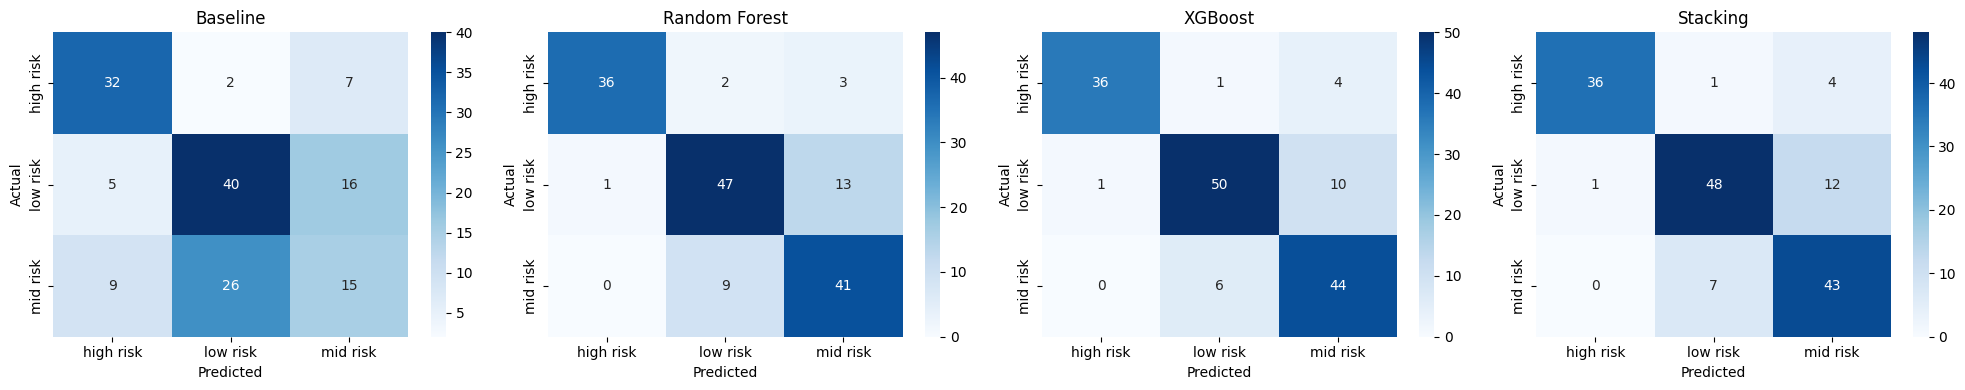

In [ ]:
# CELL 17 — Confusion matrices, side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
preds = {'Baseline': y_pred_base, 'Random Forest': y_pred_rf,
         'XGBoost': y_pred_xgb, 'Stacking': y_pred_stack}

for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1115/1525177283.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, class_names=le.classes_)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plo

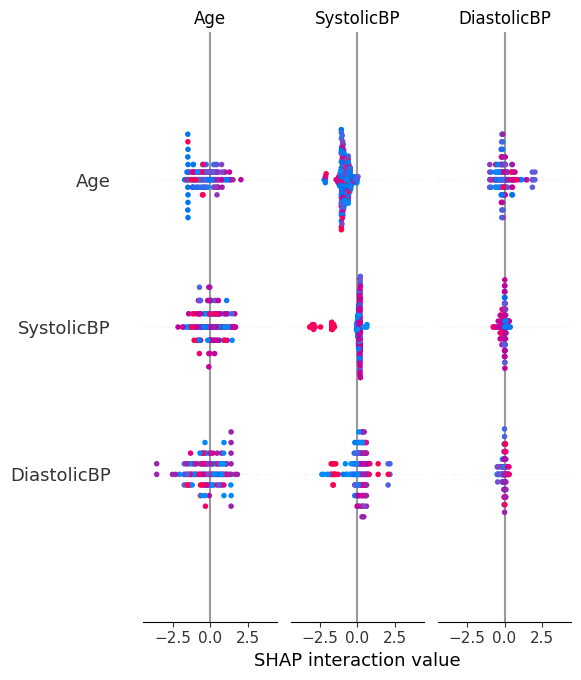

In [ ]:
# CELL 18 — Explainability: SHAP (global + local) on the best tree-based model
# Use XGBoost or RF here (SHAP TreeExplainer needs a tree model — swap in your best one)
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_scaled)

X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

# Global explanation
shap.summary_plot(shap_values, X_test_df, class_names=le.classes_)

Raw shape: (152, 8, 3)


/tmp/ipykernel_1115/1050688395.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_df, class_names=le.classes_)


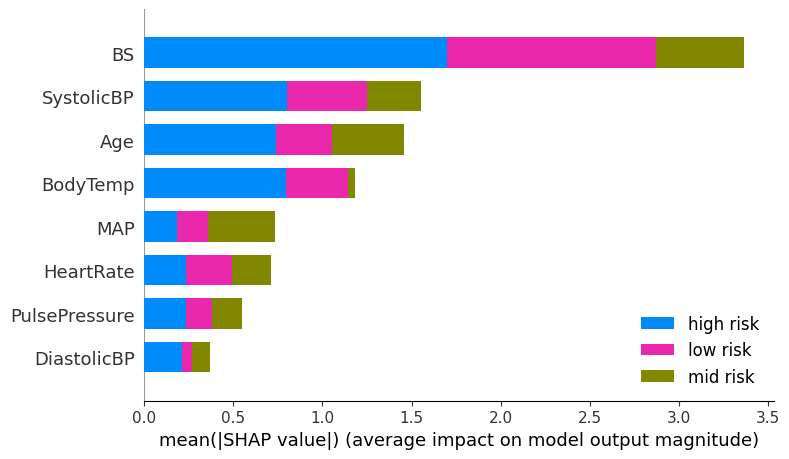

In [ ]:
# CELL 18 (fixed) — Explainability: SHAP (global + local) on the best tree-based model
explainer = shap.TreeExplainer(xgb_best)
shap_values_raw = explainer.shap_values(X_test_scaled)

X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

# Detect SHAP output format
shap_values_raw = np.array(shap_values_raw)
print("Raw shape:", shap_values_raw.shape)

if shap_values_raw.ndim == 3:
    # New format: (n_samples, n_features, n_classes) -> convert to list-per-class
    n_classes = shap_values_raw.shape[2]
    shap_values = [shap_values_raw[:, :, c] for c in range(n_classes)]
else:
    # Old format: already a list of (n_samples, n_features) arrays
    shap_values = shap_values_raw

# expected_value can be a scalar, array, or list depending on version
expected_value = explainer.expected_value
if np.isscalar(expected_value):
    expected_value = [expected_value] * len(shap_values)
else:
    expected_value = list(np.array(expected_value).flatten())

# Global explanation
shap.summary_plot(shap_values, X_test_df, class_names=le.classes_)

Predicted class: high risk


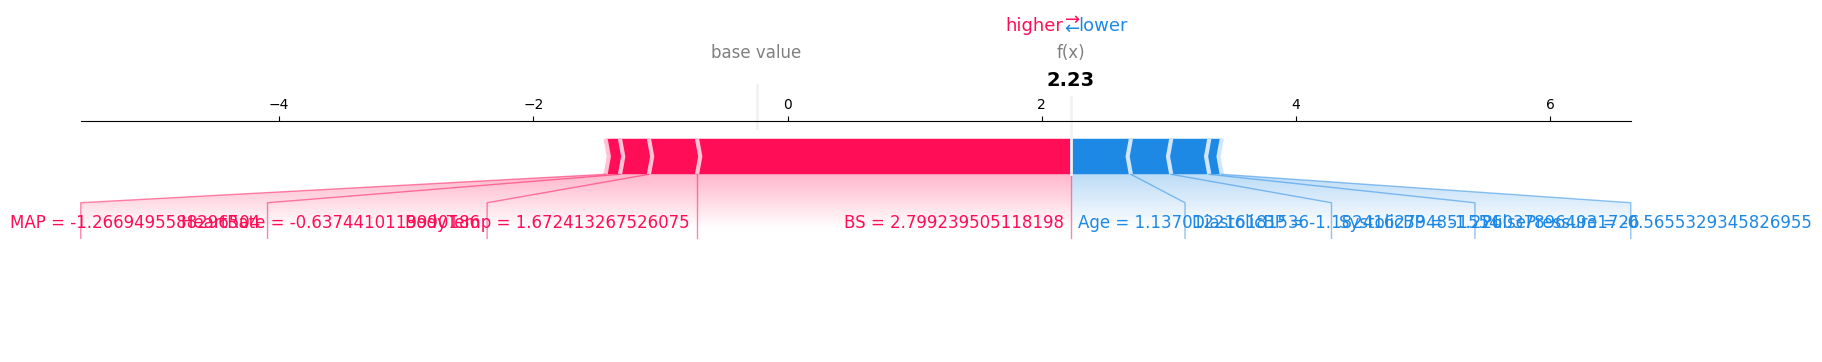

In [ ]:
# CELL 19 (fixed) — Local explanation: one individual prediction
sample_idx = 0
sample = X_test_scaled[sample_idx:sample_idx+1]
pred_class = xgb_best.predict(sample)[0]
print(f"Predicted class: {le.inverse_transform([pred_class])[0]}")

shap.force_plot(
    expected_value[pred_class],
    shap_values[pred_class][sample_idx],
    X_test_df.iloc[sample_idx],
    matplotlib=True
)

## 6. Explainability

SHAP (`TreeExplainer`) was applied to the best model (XGBoost) for both:
- **Global explanation:** a SHAP summary plot across the full test set, showing
  **Blood Sugar (BS)** and **Systolic BP** as the two most influential features
  overall, followed by Age and Body Temperature — consistent with established
  clinical risk factors for hypertensive and metabolic complications in
  pregnancy.
- **Local explanation:** a SHAP force plot for an individual test-set
  prediction and for a live synthetic demo patient (Age 32, SystolicBP 160,
  DiastolicBP 100, BS 12.5, BodyTemp 99.0, HeartRate 88 — a stage-2
  hypertensive, diabetic-range profile), which the model correctly classifies
  as **high risk**, with SystolicBP and elevated blood sugar identified as the
  primary drivers of that prediction.

---



Predicted Risk Level: high risk
Class probabilities: {'high risk': np.float32(1.0), 'low risk': np.float32(0.0), 'mid risk': np.float32(0.0)}


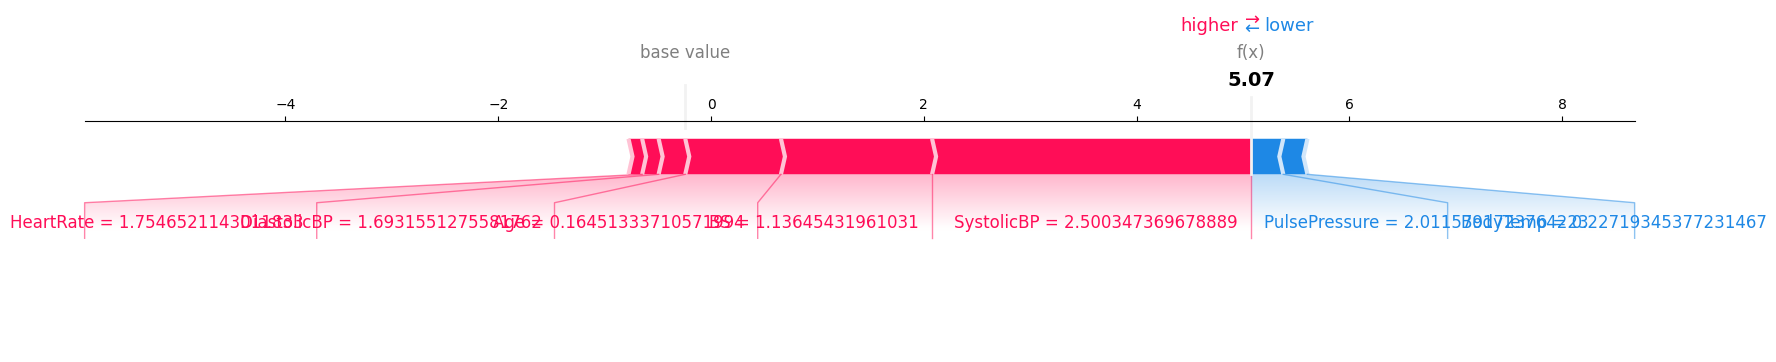

In [ ]:
# CELL 20 (fully fixed) — Live demo: predict on a realistic synthetic record
synthetic_patient = pd.DataFrame([{
    'Age': 32, 'SystolicBP': 160, 'DiastolicBP': 100, 'BS': 12.5,
    'BodyTemp': 99.0, 'HeartRate': 88
}])
synthetic_patient['PulsePressure'] = synthetic_patient['SystolicBP'] - synthetic_patient['DiastolicBP']
synthetic_patient['MAP'] = synthetic_patient['DiastolicBP'] + (synthetic_patient['PulsePressure'] / 3)
synthetic_patient = synthetic_patient[feature_cols]

synthetic_scaled = scaler.transform(synthetic_patient)

# Force pred to a plain Python int — this is what was breaking the indexing
pred = int(np.asarray(xgb_best.predict(synthetic_scaled)).flatten()[0])
pred_proba = xgb_best.predict_proba(synthetic_scaled)[0]

print("Predicted Risk Level:", le.inverse_transform([pred])[0])
print("Class probabilities:", dict(zip(le.classes_, pred_proba.round(3))))

# Local SHAP explanation for this synthetic patient
shap_vals_demo_raw = np.array(explainer.shap_values(synthetic_scaled))

if shap_vals_demo_raw.ndim == 3:
    n_classes = shap_vals_demo_raw.shape[2]
    shap_vals_demo = [shap_vals_demo_raw[:, :, c] for c in range(n_classes)]
else:
    shap_vals_demo = shap_vals_demo_raw

shap.force_plot(
    expected_value[pred],
    shap_vals_demo[pred][0],
    pd.DataFrame(synthetic_scaled, columns=feature_cols).iloc[0],
    matplotlib=True
)

## 7. Ethics, Bias, and Deployment Limitations (Q4)

**Bias and fairness.** The training data comes from a single population
(rural Bangladesh, collected via one IoT monitoring program), so the model's
risk thresholds are learned from that population's clinical baselines. Vital
sign norms (e.g. typical resting heart rate, baseline BP) can vary by
population, altitude, and measurement device. Deploying this model on a
different population without revalidation risks systematically miscalibrated
risk scores — for example, over- or under-flagging patients whose "normal"
differs from the training population's normal.

**Privacy.** The dataset contains no direct identifiers, but vital-sign
combinations recorded alongside age could, in principle, be re-identifying in
small clinic populations. Any real deployment would need to treat vitals as
sensitive health data under applicable regulations (e.g. secure storage,
access control, consent for IoT monitoring).

**Uncertainty.** The model outputs calibrated-looking class probabilities, but
on out-of-distribution or extreme inputs (as seen in the synthetic demo, which
returned a 100% confidence prediction) the model can be overconfident. High
confidence should not be read as certainty, especially for patients whose
vitals fall outside the range seen in training.

**False-negative vs. false-positive costs.** In a triage tool, a **false
negative on the high-risk class** (a genuinely high-risk patient classified as
low or mid risk) is the most dangerous failure mode, since it could delay a
needed referral. A **false positive** (an actually low-risk patient flagged as
higher risk) causes unnecessary referral burden and clinic/patient cost, but
is far less dangerous. The model's high-risk recall (0.88 for XGBoost) means
roughly 1 in 8 genuinely high-risk patients in the test set would still be
missed — a meaningful residual risk that any deployment must design around
(e.g. by pairing the model with a human clinical check on any low/mid
prediction that has borderline probability).

**The mid-risk class specifically is the model's weakest point** — even after
tuning, it has lower precision/recall than the low- and high-risk classes,
meaning the model is much better at distinguishing "clearly fine" from
"clearly at risk" than at correctly identifying the ambiguous middle tier. In
practice this is exactly the group that most needs a second, human look,
since the model itself is least confident there.

**Human oversight.** This model must be positioned as a decision-support
signal, not an autonomous diagnostic authority. All high-risk (and
borderline mid-risk) flags should route to a human clinician or trained
health worker for confirmation, not trigger automatic action.

**Limits on deployment.** This model should not be deployed for real patient
care without: (1) revalidation on the target population, (2) a clinical
governance process, (3) monitoring for drift as patient populations or
measurement devices change, and (4) a defined escalation path for borderline
and high-risk cases. As a coursework artifact, it demonstrates technical
feasibility, not clinical readiness.

---

## 8. Files in this submission

- `CIA3_ML.ipynb` — full notebook (data loading → preprocessing → EDA →
  baseline → Random Forest → XGBoost → Stacking → comparison → SHAP →
  live demo)
- `README.md` — this file
- `demo_video.mp4` — 3-minute pitch and demo video

## 9. Acknowledgements

Dataset: Ahmed, M. (2020), UCI Machine Learning Repository (CC BY 4.0), cited
above. All code in this submission was written for this assignment; no
external code was copied verbatim. Libraries used (scikit-learn, XGBoost,
imbalanced-learn, SHAP) are cited by name where used.